In [6]:
from keras.datasets import reuters
import numpy as np
import keras

(train_data, train_label), (test_data, test_label) = reuters.load_data(
    num_words=10000
)

(8982,)

In [8]:
def one_hot_encode(sequences, num_classes=46):
    results = np.zeros(shape=(len(sequences), num_classes))
    for i, label in enumerate(sequences):
        results[i][label] = 1.0
    return results

def multi_hot_encoding(sequences, num_classes):
    results = np.zeros(shape=(len(sequences), num_classes))
    for i, word in enumerate(sequences):
        results[i][word] = 1.0
    return results

In [26]:
x_train = multi_hot_encoding(train_data, num_classes=10000)
y_train = one_hot_encode(train_label)
x_test = multi_hot_encoding(test_data, num_classes=10000)
y_test = one_hot_encode(test_label)

In [27]:
reuter_model = keras.Sequential(
    [
        keras.layers.Dense(64, activation="relu"),
        keras.layers.Dense(64, activation="relu"),
        keras.layers.Dense(46, activation="softmax"),
    ]
)

top_3_accuracy = keras.metrics.TopKCategoricalAccuracy(
    k=3, name="top_3_accuracy"
)

reuter_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy", top_3_accuracy],
)

In [28]:
x_val = x_train[:1000]
partial_x_train = x_train[1000:]
y_val = y_train[:1000]
partial_y_train = y_train[1000:]

history = reuter_model.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val),
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.3973 - loss: 3.2480 - top_3_accuracy: 0.5599 - val_accuracy: 0.5180 - val_loss: 2.5029 - val_top_3_accuracy: 0.7020
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5970 - loss: 2.0110 - top_3_accuracy: 0.7293 - val_accuracy: 0.6370 - val_loss: 1.6758 - val_top_3_accuracy: 0.7510
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6974 - loss: 1.4046 - top_3_accuracy: 0.7983 - val_accuracy: 0.6910 - val_loss: 1.3405 - val_top_3_accuracy: 0.8000
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7580 - loss: 1.0844 - top_3_accuracy: 0.8523 - val_accuracy: 0.7440 - val_loss: 1.1721 - val_top_3_accuracy: 0.8300
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8166 - loss: 0.8594 - top_3_accuracy: 0.8968 - val_accuracy: 0.7720 - val_loss: 1.0620 - val_top_3_accuracy: 0.8700
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8608 - loss: 0.6757 - top_3_ac

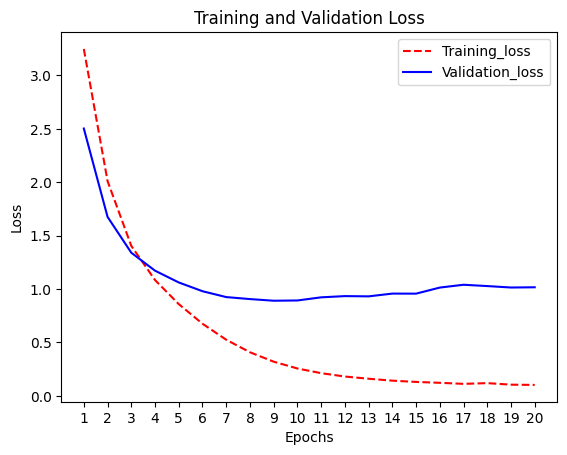

In [29]:
import matplotlib.pyplot as plt

loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, "r--", label="Training_loss")
plt.plot(epochs, val_loss, "b", label="Validation_loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Loss")
plt.legend()
plt.show()

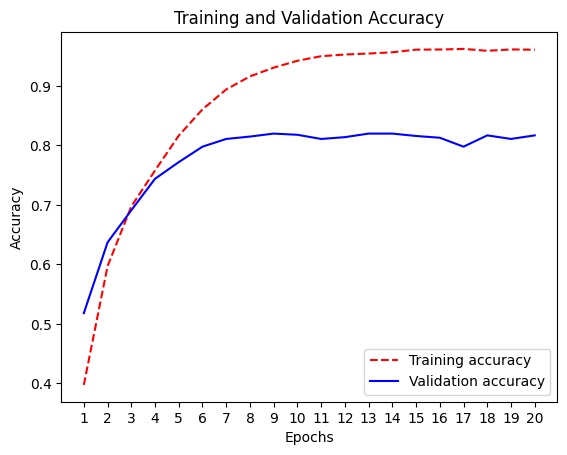

In [30]:
plt.clf()
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
plt.plot(epochs, acc, "r--", label="Training accuracy")
plt.plot(epochs, val_acc, "b", label="Validation accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.xticks(epochs)
plt.legend()
plt.show()

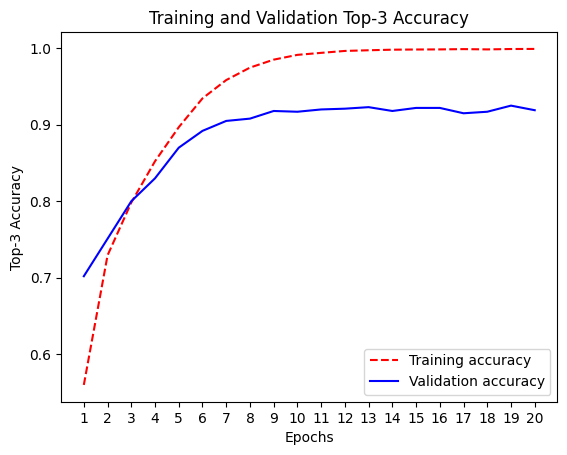

In [31]:
plt.clf()
acc=history.history["top_3_accuracy"]
val_acc = history.history["val_top_3_accuracy"]
plt.plot(epochs, acc, "r--", label="Training accuracy")
plt.plot(epochs, val_acc, "b", label="Validation accuracy")
plt.title("Training and Validation Top-3 Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Top-3 Accuracy")
plt.xticks(epochs)
plt.legend()
plt.show()

In [32]:
reuter_model = keras.Sequential(
    [
        keras.layers.Dense(64, activation="relu"),
        keras.layers.Dense(64, activation="relu"),
        keras.layers.Dense(46, activation="softmax"),
    ]
)

top_3_accuracy = keras.metrics.TopKCategoricalAccuracy(
    k=3, name="top_3_accuracy"
)

reuter_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy", top_3_accuracy],
)

history = reuter_model.fit(
    partial_x_train,
    partial_y_train,
    epochs=9,
    batch_size=512,
    validation_data=(x_val, y_val),
)

Epoch 1/9
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.4395 - loss: 3.2299 - top_3_accuracy: 0.5990 - val_accuracy: 0.5490 - val_loss: 2.4564 - val_top_3_accuracy: 0.6990
Epoch 2/9
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6037 - loss: 1.9307 - top_3_accuracy: 0.7432 - val_accuracy: 0.6500 - val_loss: 1.6138 - val_top_3_accuracy: 0.7600
Epoch 3/9
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7078 - loss: 1.3664 - top_3_accuracy: 0.8064 - val_accuracy: 0.7040 - val_loss: 1.3219 - val_top_3_accuracy: 0.8160
Epoch 4/9
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7642 - loss: 1.0731 - top_3_accuracy: 0.8530 - val_accuracy: 0.7440 - val_loss: 1.1701 - val_top_3_accuracy: 0.8460
Epoch 5/9
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8170 - loss: 0.8493 - top_3_accuracy: 0.8943 - val_accuracy: 0.7790 - val_loss: 1.0692 - val_top_3_accuracy: 0.8700
Epoch 6/9
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8582 - loss: 0.6660 - top_3_accuracy

In [34]:
reuter_model.evaluate(x_test, y_test)

71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 725us/step - accuracy: 0.7836 - loss: 0.9835 - top_3_accuracy: 0.8967


[0.9835412502288818, 0.7836152911186218, 0.8967052698135376]